<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/AIML_Image_Classification_VM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score
from sklearn.model_selection import train_test_split

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
directory = '/content/drive/MyDrive/dog dataset-20260720T013156Z-1-001/dog dataset'

In [12]:
Name = []
for file in os.listdir(directory):
  Name+=[file]
print(Name)
print(len(Name))

['Afgan Hound dog', 'Bugg dog', 'Boxer dog', 'Alaskan Malamute dog', 'Affenhuahua dog', 'Akita dog', 'Beagle dog', 'Bichon Frise dog', 'Bocker dog', 'Bulldog dog', 'Auggie dog', 'Borzoi dog', 'Belgian Tervuren dog', 'American Bulldog dog']
14


In [13]:
N=[]
for i in range(len(Name)):
    N+=[i]

mapping=dict(zip(Name,N))
reverse_mapping=dict(zip(N,Name))

def mapper(value):
    return reverse_mapping[value]

In [14]:
dataset=[]
testset=[]
count=0

for file in os.listdir(directory):
    path=os.path.join(directory,file)
    t=0
    for im in os.listdir(path):
        image=load_img(os.path.join(path,im), color_mode='rgb', target_size=(180,180))
        image=img_to_array(image)
        image=image/255.0
        if t<=20:
            dataset+=[[image,count]]
        else:
            testset+=[[image,count]]
        t+=1
    count=count+1

In [15]:
data, labels0 = zip(*dataset)
test, testlabels0 = zip(*testset)

In [16]:
labels1=to_categorical(labels0)
labels = np.array(labels1)

In [17]:
data = np.array(data)
test = np.array(test)

In [18]:
trainx, testx, trainy, testy = train_test_split(data, labels, test_size=0.2, random_state=44)

In [19]:
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)

(201, 180, 180, 3)
(51, 180, 180, 3)
(201, 14)
(51, 14)


In [20]:
datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, rotation_range=20, zoom_range=0.2,
                             width_shift_range=0.2, height_shift_range=0.2, shear_range=0.1, fill_mode="nearest")

In [21]:
pretrained_model3 = tf.keras.applications.DenseNet201(input_shape=(180,180,3), include_top=False, weights='imagenet', pooling='avg')
pretrained_model3.trainable = False

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
inputs3 = pretrained_model3.input
X3 = tf.keras.layers.Dense(128, activation='relu')(pretrained_model3.output)
outputs3 = tf.keras.layers.Dense(14, activation='softmax')(X3)
model = tf.keras.Model(inputs=inputs3, outputs=outputs3)

In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
his = model.fit(datagen.flow(trainx, trainy, batch_size=32), validation_data=(testx, testy), epochs = 15)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 370ms/step - accuracy: 0.6567 - loss: 1.1062 - val_accuracy: 0.4902 - val_loss: 1.7323
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 403ms/step - accuracy: 0.7065 - loss: 1.0294 - val_accuracy: 0.3725 - val_loss: 1.9266
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 242ms/step - accuracy: 0.7413 - loss: 0.9322 - val_accuracy: 0.4706 - val_loss: 1.8328
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.7761 - loss: 0.7874 - val_accuracy: 0.4706 - val_loss: 1.8951
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step - accuracy: 0.7861 - loss: 0.6871 - val_accuracy: 0.5294 - val_loss: 1.8280
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.7463 - loss: 0.7330 - val_accuracy: 0.4706 - val_loss: 1.8922
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 247ms/step - accuracy: 0.7811 - loss: 0.7369 - val_accuracy: 0.5098 - val_loss: 1.8961
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.8657 - loss: 0.5516 - val_accuracy: 0.4706 - val_loss:

In [26]:
y_pred = model.predict(testx)
pred = np.argmax(y_pred, axis = 1)
ground = np.argmax(testy, axis =1)
print(classification_report(ground, pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 52s 27s/step
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           3       0.67      0.67      0.67         6
           4       0.75      0.30      0.43        10
           5       0.40      1.00      0.57         2
           6       0.20      0.33      0.25         3
           7       0.80      0.57      0.67         7
           8       0.50      1.00      0.67         2
           9       1.00      0.50      0.67         2
          10       0.00      0.00      0.00         4
          11       0.20      0.67      0.31         3
          12       0.00      0.00      0.00         4
          13       0.33      0.33      0.33         3

    accuracy                           0.47        51
   macro avg       0.47      0.51      0.45        51
weighted avg       0.53      0.47      0.46        51



In [27]:
get_acc = his.history['accuracy']
value_acc = his.history['val_accuracy']
get_loss = his.history['loss']
validation_loss = his.history['val_loss']

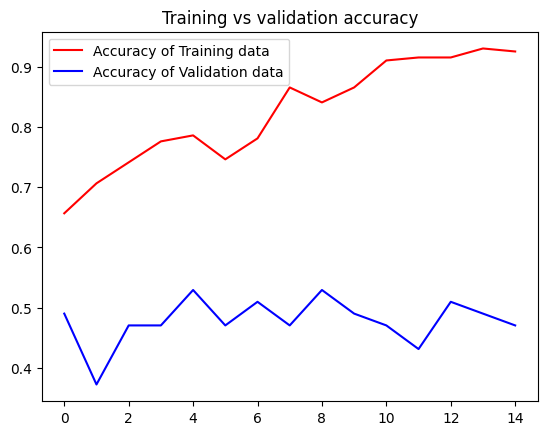

<Figure size 640x480 with 0 Axes>

In [28]:
epochs = range(len(get_acc))
plt.plot(epochs, get_acc, 'r', label='Accuracy of Training data')
plt.plot(epochs, value_acc, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

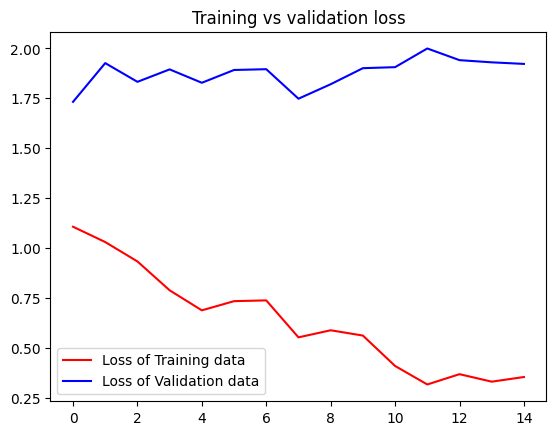

<Figure size 640x480 with 0 Axes>

In [29]:
epochs = range(len(get_loss))
plt.plot(epochs, get_loss, 'r', label='Loss of Training data')
plt.plot(epochs, validation_loss, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss')
plt.legend(loc=0)
plt.figure()
plt.show()

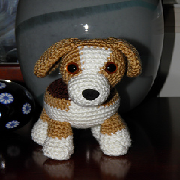

In [31]:
load_img("/content/drive/MyDrive/dog dataset-20260720T013156Z-1-001/dog dataset/Beagle dog/Image_21.JPG", target_size=(180,180))

In [33]:
image = load_img("/content/drive/MyDrive/dog dataset-20260720T013156Z-1-001/dog dataset/Beagle dog/Image_21.JPG", target_size=(180,180))
image=img_to_array(image)
image=image/255.0
prediction_image=np.array(image)
prediction_image= np.expand_dims(image, axis=0)

In [34]:
prediction=model.predict(prediction_image)
value=np.argmax(prediction)
move_name = mapper(value)
print(move_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step
Beagle dog
